# $N_2$ Molecule: bond stretching and multi-Slater determinant trial wavefunctions

---

<font size="5"><b>Goal:</b>
This example demonstrates how to compute the potential energy curve (PEC) of a diatomic molecule
using an appropriate trial wavefuncton.
</font>

&nbsp;

## What you will learn

---

<font size="4">

1. How to select the number of Slater determinants to include in the trial wavefunction, balancing computational cost and accuracy
2. How to automate the computation of a potential energy curve using afqmctools within Python

</font>

&nbsp;

## Run the code block below (shift+enter or click the play button) to set up the example

In [1]:
# Run me (shift+enter or click the play button) to setup the example!
from pathlib import Path

import h5py as h5
import numpy as np
from pyscf import gto,scf,mcscf

from afqmctools.utils.pyscf_utils import load_from_pyscf_chk_mol
from afqmctools.hamiltonian.mol import write_hamil_mol
from afqmctools.wavefunction.mol import write_cas_wfn
from afqmctools.inputs.from_hdf import write_json
from afqmctools.hamiltonian.io import write_to_hdf5

from stats.scalar_dat import analyze_scalar_data

from tutorial_utils import run_afqmc, get_scratch_dir

# Note: set a scratch directory for the files that will be generated
home = Path.home()
scratch_dir = get_scratch_dir("n2_pec",home / ".scratch")

## The Nitrogen dimer
---

<font size="4">

Diatomic molecules display strong static electron correlation effects (i.e. correlation due to many energetically proximate electron configurations)
in the intermediate bond length regime.
The $N_2$ molecule is a notorious example and has historically been used to benchmark the accuracy of quantum chemistry approaches [1].
Below is a plot of the error in the energy, relative to exact results from DRMG,
from reference [1].

<!---
<div>
<img src="./figs/NitrogenMolecule.png" width="500"/>
</div>
--->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/984d8f6514d4af38baf14fd45a2d29c0b42cf95c8335c9a92c7cefb169a830b7/ReferenceFigure.png">
</div>

We have inlcude both the quantum chemistry "gold standard" CCSD(T) results, in orange, as well as CCSDT for reference.
There are two AFQMC curves, one using a UHF trial wavefunction (in pink), and
one using a truncated CASSCF(12o,6e) trial wavefunction (in violet).
For AFQMC, the stochastic uncertainty is smaller than the symbol size.

For bondlenghts close to the equilibrium bond length of 2.118 Bohr,
AFQMC agrees with exact results to well within chemical accuracy (  $ 1 kcal/mol ≈ 1.6 mE_{Ha}$) regardless of the trial wavefunction used.
For intermediate and streched bond lengths, the trial wavefunction from MCSCF (in this case, from CASSCF(12o,6e)) is necessary to chemical accuracy using AFQMC accross the PEC.
Still, for all nearly all bond lengths, AFQMC with a UHF trial wavefunction produces more accurate results,
in terms of absolute error, than either the quantum chemistry "gold standard" method CCSD(T) or CCSDT.
AFQMC with a CASSCF(12o,6e) trial wavefunction outperforms both CCSD(T) and CCSDT in terms of accuracy at all bond lengths.

<font size="4">
Next, we will reproduce the PEC of the Nitrogen dimer using AFQMC / CASSCF(12o,6e) trial wavefunctions.
</font>


&nbsp;

### References:

---

[1] W. A. Al-Saidi, S. Zhang, H. Krakauer. "Bond breaking with auxiliary-field quantum Monte Carlo." *J. Chem. Phys.* **127**, 144101 (2007).  

</font>

&nbsp;

## Converging AFQMC in the quality of the trial wavefunction
---

<font size="4">

As we saw in [ Using CI trial wavefunctions as a trial wavefunction ](),
AFQMC trial wavefunctions are typically multi-Slater determinant expansions with form,

$$
| \Psi_T \rangle = \sum_n^{N_{det}} C_{n} | \Phi_n \rangle,
$$

where $ C_{n} $ are CI coefficients,
and $| \Phi_n \rangle$ are Slater determinants.
Typically, CI trial wavefunctions are truncated CASSCF or selected CI (SCI) wavefunctions.

For quantum chemistry, AFQMC uses the phaseless approximation in order to control the fermionic sign / phase problem at the cost of introducing a removable bias.
This bias can be systematically removed by using a better trial wavefunction.
If we start with a decent CASSCF or SCI wavefunction, then we can characterize the "quality" of a trial wavefunction by the number of Slater determinants that are included in the trial wavefunction, $N_{det}$.

&nbsp;

<b>A critical step in achieving high-accuracy results, therefore, is to converge the AFQMC energy in $N_{det}$</b>

SAFIRE provides a keyword in the "wavefunction" json input block to limit the number of Slater determinants, "ndets_to_read", that are actually read from the HDF5 wavefunction file. Here is a sample json input block.

```json
{
  "afqmc": {
    "project": {
      "id": "qmc",
      "series": 0,
      "mixed_precision": false
    },
    "execute": {
      "walker_set": {
        "walker_type": "COLLINEAR"
      },
      "wavefunction": {
        "filename": "your_wfn_file.h5",
        "ndets_to_read": 500
      },
      "timestep": 0.01,
      "steps": 10000,
      "n_walkers_per_mpi_task": 100,
      "seed": 42
    }
  }
}
```

In this case, a maximum of 500 Slater determinants will be read from "your_wfn_file.h5" regarldess of how many Slater determinants were
written to the file.
We will save significantly more Slater determinants to the wavefunction HDF5 file than we expect to need.
This allows us to reuse the same wavefunction file while controlling the trial wavefunction quality via the "ndets_to_read" parameter.

</font>

&nbsp;

### Getting an orthonormal basis and a trial wavefunction

---

We will now setup an AFQMC calculation. As you should now be familiar with from previous tutorials, we will need to choose an orthonormal orbital basis to work within.
Since we will be using CASSCF trial wavefunctions, it is convenient to use the set of optimized CASSCF orbitals,
$$
\phi_i (\vec{r}) = \sum_μ C_{\mu i} g_{\mu} (\vec{r}),
$$
as a basis.

<b>Run the code block below in order to run CASSCF in PySCF</b>
(alternatively, run your favorite Quantum Chemistry code, and save the CASSCF wavefunction in the wavefunction HDF5 file).

In [2]:
# Here, we'll generate the mol object

delta = 3.0 # Bohr

atom = f'''
N 0. 0. {delta/2}
N 0. 0. -{delta/2}
'''
mol = gto.M(
    atom = atom,
    basis = 'ccpvdz',
    unit = 'Bohr'
)

# run CASSCF to get an orbital basis AND a CAS wavefunction
casscf_chkfile = 'rhf_chkfile.h5'

rhf = scf.RHF(mol)
rhf.chkfile = scratch_dir / casscf_chkfile
rhf.run()

mc = mcscf.CASSCF(rhf, 12, 6).run() # (12o,6e)

# save some extra data to the checkpoint file
with h5.File(scratch_dir/casscf_chkfile, 'a') as fp:
    write_to_hdf5(fp,'mcscf/ci', data=mc.ci)
    write_to_hdf5(fp,'mcscf/ncore', data=mc.ncore)
    write_to_hdf5(fp,'mcscf/ncas', data=mc.ncas)

# write the CAS wavefunction to a file
write_cas_wfn(
    mol=mol,
    cas_chkfile=scratch_dir / casscf_chkfile,
    tol_trunc=1.0e-4, # use a small value to save *many* determinants.
    outname=scratch_dir / 'afqmc.h5',
    max_det=10000
)

converged SCF energy = -108.606225806528


CASSCF energy = -108.916484583939


CASCI E = -108.916484583939  E(CI) = -10.6184452858851  S^2 = 0.0000000


{'ci': array([[ 8.40812819e-01, -5.13783658e-08, -1.24803193e-06, ...,
        -1.54244153e-20, -7.82520268e-19, -2.54323709e-04],
       [-5.13781949e-08, -2.74960408e-02, -7.43224254e-03, ...,
         1.24036367e-18, -4.75421054e-18,  9.66943201e-10],
       [-1.24803194e-06, -7.43224274e-03, -2.57476076e-01, ...,
         3.96099306e-18,  2.28914616e-18,  2.22906551e-08],
       ...,
       [-1.54241070e-20,  1.24036234e-18,  3.96098645e-18, ...,
        -9.14512317e-07, -1.78204823e-21,  8.34449802e-20],
       [-7.82517975e-19, -4.75420663e-18,  2.28910733e-18, ...,
        -1.41269199e-21, -9.14512317e-07,  1.01574415e-19],
       [-2.54323709e-04,  9.66943413e-10,  2.22906550e-08, ...,
         8.34453229e-20,  1.01572577e-19,  1.31610084e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 4204
PHMSD trial wavfunction -> using uhf-like walkers


### Checkpoint
---

At this point, you should have a CASSCF trial wavefunction saved in an AuxliaryFields HDF5 file (we used "afqmc.h5" as our filename, but you are free to use whatever name you would like).

You will also need the CASSCF orbitals in order to represent the Hamiltonian in that basis.
In PySCF, these are simply saved within the Checkpoint (*.chk) file.


## Save the Hamiltonian
---

We have already chosen the set of CASSCF orbitals as a trial wavefunction.
We will now build the Hamiltonian in the basis of CASSCF orbitals, and save it to an SAFIRE HDF5 Hamiltonian file.

afqmctools provides a helper function, `load_from_pyscf_chk_mol()`,  to read all of the necessary information from a PySCF checkpoint file.

<div class="alert alert-block alert-info">
<b>Note:</b>
    By default, load_from_pyscf_chk_mol() will try to read data from an "scf" group in a PySCF checkpoint file. Set the "base" parameter to "mcscf" to read a CASSCF wavefunction.
</div>



In [3]:
# Save the Hamiltonian
basis_scf_data = load_from_pyscf_chk_mol(
    chkfile = scratch_dir / casscf_chkfile,
    base = 'mcscf'
)

# write Hamiltonian
write_hamil_mol(
    basis_scf_data,
    hamil_file = scratch_dir / 'afqmc.h5',
    chol_cut = 1e-5,
    verbose=True
)

 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performing modified Cholesky decomposition on ERI tensor.
 # Generating Cholesky decomposition of ERIs.
 # max number of cholesky vectors = 280
        iteration      max_residual              time
                0  4.1222527349e+00  2.8486251831e-03
                1  4.0952987566e+00  2.6035308838e-04
                2  6.0284434624e-01  2.2149085999e-04
                3  5.6420104042e-01  1.9502639771e-04
                4  2.1362550866e-01  1.5783309937e-04
                5  2.0685452640e-01  1.6260147095e-04
                6  1.5487209282e-01  2.2006034851e-04
                7  1.5487209282e-01  2.0456314087e-04
                8  1.5416490193e-01  1.9645690918e-04
                9  1.5416490193e-01  1.9550323486e-04
               10  1.4782887263e-01  2.1028518677e-04
               11  1.4392245562e-01  2.0051002502e-04
               12  1.1601111795e-01  1.7976760864e-04
               13  1

### Checkpoint

----

In addition to the trial wavefunction HDF5 file from before, you should also now have a Hamiltonian HDF5 file. We saved both the trial wavefunction and the Hamiltonian into a file called "afqmc.h5", but you can use whatever file name(s) you would like. Simply update the code blocks based on your filenames.

### Run SAFIRE
--------------

<font size="4">

Before we move on to computing the PEC, we need to converge the AFQMC energy in $N_{det}$.
To avoid doing this for every point on the PEC, we will simply choose a point on the PEC where we expect the most static correlation, converge the AFQMC energy in $N_{det}$ at that point, and use that converged $N_{det}$ value uniformly accross the entire PEC.
This avoids running many calculations at each point on the PEC to check convergence at the cost of perhaps too many Slater determinants at some points
on the PEC.

<b>We will automate this using Python and the tutorial helper function, run_afqmc().</b>

Again, we will use the "ndets_to_read" keyword in the "wavefunction" input block to limit the number of Slater determinants.
In the code block below, you will notice that we are setting,

```python
execute_options["wavefunction"] = { "ndets_to_read" : ndet }
```

in the "execute_options" dictionary.
`write_json()` will ***append*** settings within an existing input block when they are passed in this way.
For example,

```
write_json("afqmc.json","wfn.h5",exec_opts={ "ndets_to_read" : 500 })
```

will generate a "wavefunction" block that points to the wavefunction file, with the following contents:

```json
{
  "afqmc": {
    "project": {
      "id": "qmc",
      "series": 0,
      "mixed_precision": false
    },
    "execute": {
      "walker_set": {
        "walker_type": "COLLINEAR"
      },
      "wavefunction": {
        "filename": "afqmc.h5",
        "ndets_to_read": 500
      },
      "timestep": 0.01,
      "steps": 10000,
      "n_walkers_per_mpi_task": 10
    }
  }
}
```

</font>

<b>Run the code block below in order to compute $E_{AFQMC}$ vs $N_{det}$</b>
Note: This might take some time. You might want to run this on a computing cluster instead.

&nbsp;

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 56.146303 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/n2_pec/Ndet_14/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           



AFQMC Energy   -109.085588 +/-   0.000908 8.34  5.0/100.0


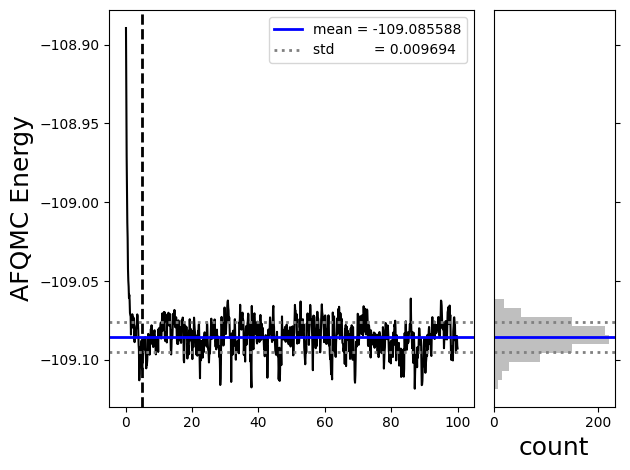

 [Result] -109.08558812717114 0.0009083434892984729
Running AFQMC locally with 64 mpi tasks


AFQMC ran in 82.501692 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/n2_pec/Ndet_50/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.087062 +/-   0.000474 5.23  5.0/100.0


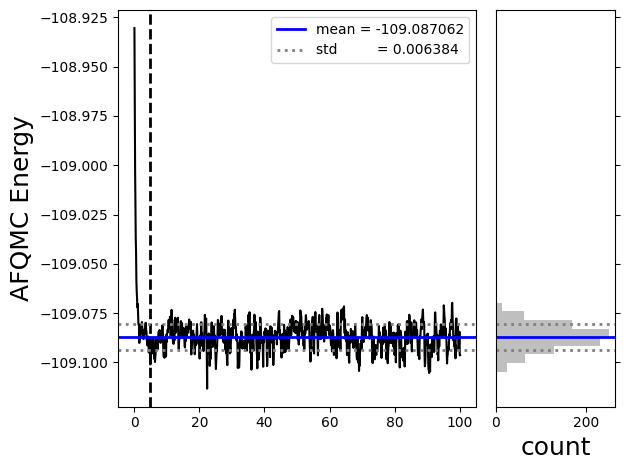

 [Result] -109.08706171835932 0.0004737165155843659
Running AFQMC locally with 64 mpi tasks


AFQMC ran in 178.336457 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/n2_pec/Ndet_200/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.088176 +/-   0.000353 4.87  5.0/100.0


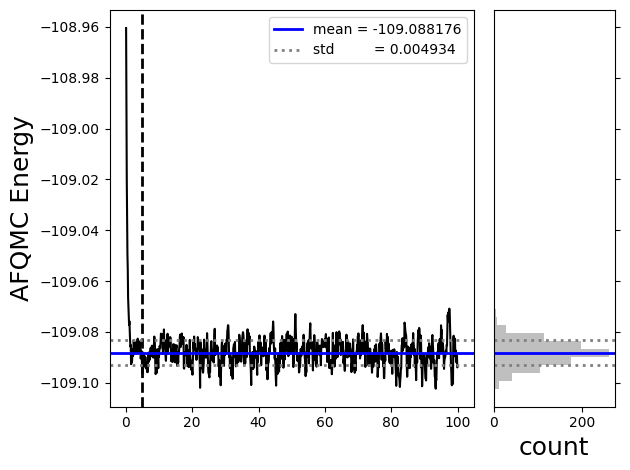

 [Result] -109.0881764800644 0.00035327403985639503
Running AFQMC locally with 64 mpi tasks


AFQMC ran in 289.132405 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/n2_pec/Ndet_500/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.088433 +/-   0.000311 4.82  5.0/100.0


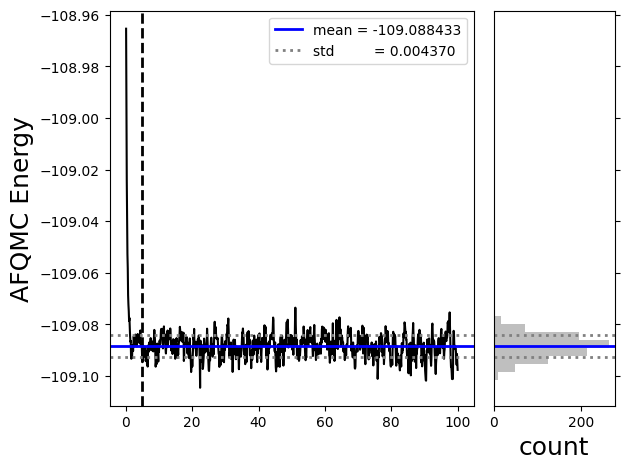

 [Result] -109.08843291374986 0.0003112794249348245
Running AFQMC locally with 64 mpi tasks


AFQMC ran in 400.210107 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/n2_pec/Ndet_1000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.088669 +/-   0.000301 4.98  5.0/100.0


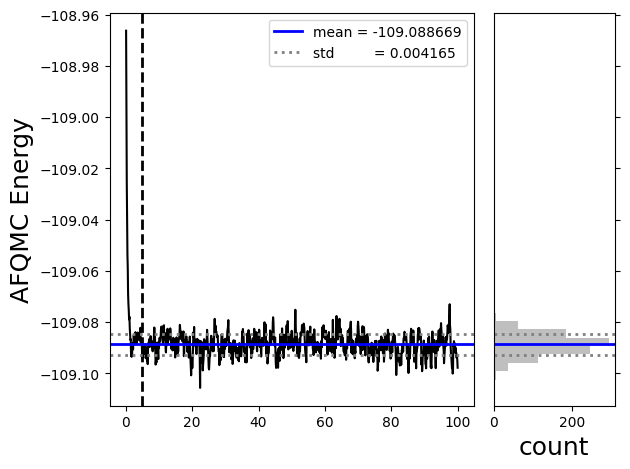

 [Result] -109.0886686668698 0.0003014906785890868


In [4]:
num_mpi_tasks = 64

# some shared parameters for the AFQMC run
execute_options = {
    "timestep": 0.01,
    "steps": 10000,
    "measure_interval_multiplier": 1,
    "population_control_interval" : 10,
    "walker_ortho_interval" : 10 ,
    "n_walkers_per_mpi_task": 20,
    "seed" : 42
}


ndets = [14,50,200,500,1000] # list of Ndet values to run
energies = []
stochastic_uncertainties = []
# compute E(N_det) for the CAS trial wavefunction
for ndet in ndets:

    # make a sub-scratch dir for better book keeping
    scratch_dir_local = scratch_dir / f"Ndet_{ndet}"
    scratch_dir_local.mkdir(parents=True, exist_ok=True)

    execute_options["wavefunction"] = { "ndets_to_read" : ndet }

    write_json(
        scratch_dir_local/ "afqmc.json",
        fwfn0=scratch_dir / "afqmc.h5",
        exec_opts=execute_options
    )

    # run AFQMC
    run_afqmc(
        run_dir=scratch_dir_local,
        run_mode="local_cpu",
        timeout_mins=100,
        input_file="afqmc.json",
        np=num_mpi_tasks,         # number of MPI tasks
        output_file="afqmc.out"   # optionally direct output to file instead of here
    )

    settings = dict(
        fname = scratch_dir_local/"qmc.s000.scalar.dat",
        xaxis = "time",
        nequil = 5,
        trace = True
    )

    E,dE = analyze_scalar_data(settings)

    energies.append(E)
    stochastic_uncertainties.append(dE)

    print(f" [Result] {E} {dE}")


### Plot $E_{AFQMC}$ vs $N_{det}$
---------------------------------


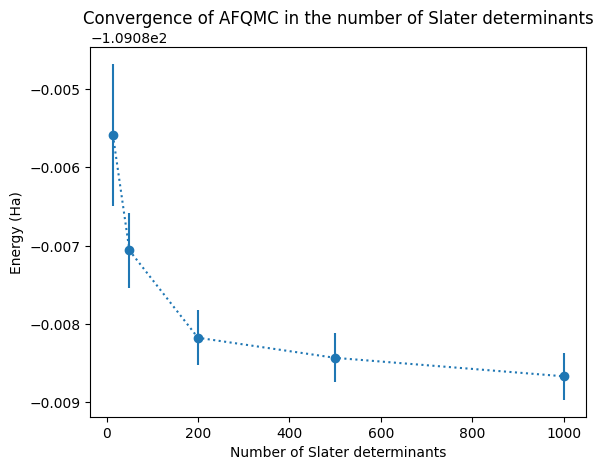

In [5]:
# plot the results
import matplotlib.pyplot as plt

plt.errorbar(ndets, energies, yerr=stochastic_uncertainties, fmt='o:')
plt.xlabel("Number of Slater determinants")
plt.ylabel("Energy (Ha)")
plt.title("Convergence of AFQMC in the number of Slater determinants")
plt.show()

### Result
---

From the plot of energy vs $N_{det}$, we have converged the AFQMC energy to within our target stochastic uncertainty of less than 1.6 $mE_{Ha}$ at about $N_{det} = 500$.
Since we performed this test at a point on the PEC where there are strong static correlation effects, we expect this
value to provide converged results across the PEC.
Now, we can automate the calculation of the PEC using this value for $N_{det}$.

&nbsp;

## Automating the computation of the PEC using Python / afqmctools
---

<font size="4">
Now that we have converged $E_{AFQMC}$ in $N_{det}$, we are ready to compute the PEC.
In the code block below, we have included a function that performs all of the steps that we have already performed (excluding converging $E_{AFQMC}$ in $N_{det}$) given a value of the $N_2$ bond length, $\delta_{N-N}$.

Sepcifically, given $\delta_{N-N}$ and `ndets_to_read`, the function automates:

1. running CASSCF using PySCF (for convenience), and saving a truncated CASSCF wavefunction to the SAFIRE HDF5 format.
2. building and saving the Hamiltonian in the basis of CASSCF orbitals to the AuxilariyFields HDF5 format.
3. writing the json input file, with our choosen value of `ndets_to_read`, and running SAFIRE.
4. Extracting the AFQMC energy using the stats module.


<b>
Run the cell block below in order to load the "run_afqmc_on_dimer()" function into memory.
</b>

</font>

&nbsp;

In [6]:
def run_afqmc_on_dimer(delta,ndets_to_read=None,scratch_root_dir=home / ".scratch", num_mpi_tasks=16):

    scratch_dir = get_scratch_dir(f"N2_bondlength_{delta:.4f}", scratch_root_dir)

    print(f"Running AFQMC on dimer with bond length {delta:.4f} Angstroms")
    print("  [+] scratch_dir: ", scratch_dir)

    # 1. run CASSCF to get a basis and a trial wavefunction
    atom = f'''
    N 0. 0. {delta/2}
    N 0. 0. -{delta/2}
    '''
    mol = gto.M(
        atom = atom,
        basis = 'ccpvdz',
        unit = 'Bohr'
    )


    casscf_chkfile = 'rhf_chkfile.h5'

    rhf = scf.RHF(mol)
    rhf.chkfile = scratch_dir / casscf_chkfile
    rhf.run()

    mc = mcscf.CASSCF(rhf, 12, 6).run() # (12o,6e)

    # save some extra data to the checkpoint file
    with h5.File(scratch_dir/casscf_chkfile, 'a') as fp:
        write_to_hdf5(fp,'mcscf/ci', data=mc.ci)
        write_to_hdf5(fp,'mcscf/ncore', data=mc.ncore)
        write_to_hdf5(fp,'mcscf/ncas', data=mc.ncas)

    # write the CAS wavefunction to a file
    fout = scratch_dir / 'afqmc.h5'

    write_cas_wfn(
        mol=mol,
        cas_chkfile=scratch_dir / casscf_chkfile,
        tol_trunc= 1.0e-4,
        outname=fout,
        max_det=10000
    )

    # 2. write the Hamiltonian
    basis_scf_data = load_from_pyscf_chk_mol(scratch_dir / casscf_chkfile, 'scf')

    chol_tol = 1e-5

    # write Hamiltonian
    write_hamil_mol(
        basis_scf_data,
        fout,
        chol_tol,
        verbose=True
    )

    # write json file
    afqmc_execution_options = {
        "timestep": 0.01,
        "steps": 3200,
        "measure_interval_multiplier": 1,
        "population_control_interval" : 10,
        "walker_ortho_interval" : 10 ,
        "n_walkers_per_mpi_task": 20,
        "seed" : 42,
        "wavefunction" : { "ndets_to_read" : ndets_to_read }
    }

    write_json(
        scratch_dir/ "afqmc.json",
        fwfn0=scratch_dir / "afqmc.h5",
        exec_opts=afqmc_execution_options
    )


    print("Running AFQMC",flush=True)

    # run afqmc
    run_afqmc(
        run_dir=scratch_dir,
        run_mode="local_cpu",
        timeout_mins=100,
        input_file="afqmc.json",
        np=num_mpi_tasks,             # number of MPI tasks
        output_file="afqmc.out"   # optionally direct output to file instead of here
    )

    settings = dict(
        fname = scratch_dir/"qmc.s000.scalar.dat",
        xaxis = "time",
        nequil = 5,
        trace = True
    )

    E,dE = analyze_scalar_data(settings)

    print(f" [Result] {delta}  {E} {dE}")

    return delta, E, dE


### Compute the PEC
-------------------

Now we can use the `run_afqmc_on_dimer()` function to compute the PEC of the $N_2$ molcule.

Running AFQMC on dimer with bond length 2.1180 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_2.1180
converged SCF energy = -108.949377879017


CASSCF energy = -109.131212351822


CASCI E = -109.131212351822  E(CI) = -13.2882450665793  S^2 = 0.0000000


{'ci': array([[-9.60270811e-01, -1.95616751e-05, -1.31630886e-06, ...,
         9.92117557e-05,  9.98913291e-05, -3.72399432e-05],
       [-1.95616751e-05,  7.95166400e-02, -4.13964203e-02, ...,
        -7.49252751e-05, -1.67208316e-04,  1.20509505e-04],
       [-1.31630886e-06, -4.13964203e-02,  4.17858160e-02, ...,
         1.52481839e-04,  6.39127436e-06, -7.79879969e-05],
       ...,
       [ 9.92117557e-05, -7.49252751e-05,  1.52481839e-04, ...,
         2.88194093e-05,  3.38230085e-06, -4.37934466e-06],
       [ 9.98913291e-05, -1.67208316e-04,  6.39127436e-06, ...,
         3.38230085e-06,  2.88808635e-05, -4.41864448e-06],
       [-3.72399432e-05,  1.20509505e-04, -7.79879969e-05, ...,
        -4.37934466e-06, -4.41864448e-06,  1.47994207e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 5500
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performi

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 81.419015 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_2.1180/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.281703 +/-   0.000671 3.71  5.0/32.0


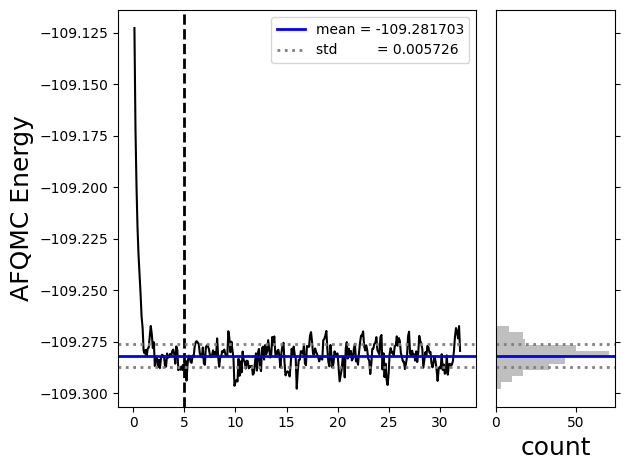

 [Result] 2.118  -109.28170267305917 0.0006713373489929643
Running AFQMC on dimer with bond length 2.4000 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_2.4000


converged SCF energy = -108.866810689943


CASSCF energy = -109.074562067335


CASCI E = -109.074562067335  E(CI) = -12.3271332432002  S^2 = 0.0000000


{'ci': array([[-9.40996503e-01,  1.55118075e-08, -4.79108960e-08, ...,
        -8.44353204e-10, -1.97630780e-09, -8.90823954e-14],
       [ 1.55118075e-08,  4.83227974e-02, -5.30331758e-02, ...,
        -9.18667852e-05, -2.52989370e-04,  6.57202139e-09],
       [-4.79108960e-08, -5.30331758e-02,  1.22215585e-01, ...,
         1.97092094e-04,  5.15260674e-04, -1.20380634e-08],
       ...,
       [-8.44353204e-10, -9.18667852e-05,  1.97092094e-04, ...,
         1.01039486e-05,  2.53426770e-06, -1.86791725e-10],
       [-1.97630780e-09, -2.52989370e-04,  5.15260674e-04, ...,
         2.53426770e-06,  1.57837528e-05, -5.18413796e-10],
       [-8.90823954e-14,  6.57202139e-09, -1.20380634e-08, ...,
        -1.86791725e-10, -5.18413796e-10,  2.37165774e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 3872
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performi

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 83.077481 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_2.4000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.240853 +/-   0.000760 4.71  5.0/32.0


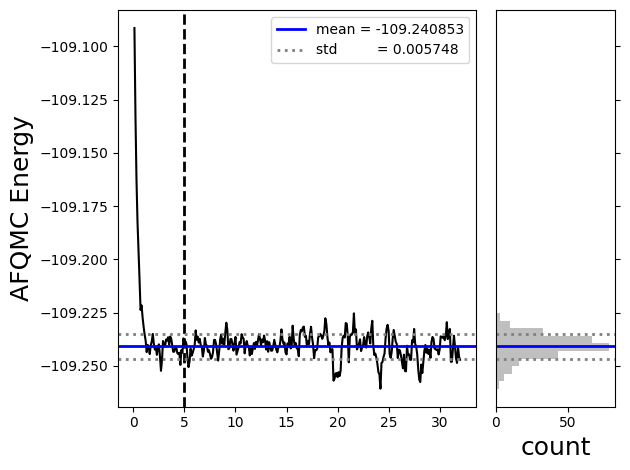

 [Result] 2.4  -109.24085315312836 0.0007595556082826983
Running AFQMC on dimer with bond length 2.7000 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_2.7000
converged SCF energy = -108.737399722424


CASSCF energy = -108.989740714417


CASCI E = -108.989740714417  E(CI) = -11.3408345718633  S^2 = 0.0000000


{'ci': array([[-9.03828276e-01,  4.73273823e-12, -1.29105551e-11, ...,
        -2.17469257e-12,  4.53286807e-12, -1.03533269e-15],
       [ 4.73273823e-12,  1.70759749e-01,  6.53148326e-02, ...,
         1.56590075e-04, -2.52149354e-04,  2.83537232e-15],
       [-1.29105551e-11,  6.53148326e-02,  5.43250760e-02, ...,
         2.21932448e-04, -1.64199876e-04, -1.57089208e-15],
       ...,
       [-2.17469257e-12,  1.56590075e-04,  2.21932448e-04, ...,
         4.37962677e-06, -1.21980914e-06, -8.74978659e-18],
       [ 4.53286807e-12, -2.52149354e-04, -1.64199876e-04, ...,
        -1.21980914e-06,  6.79746391e-06, -6.72498207e-17],
       [-1.03533269e-15,  2.83537232e-15, -1.57089208e-15, ...,
        -8.74978659e-18, -6.72498207e-17,  1.91904940e-06]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 3825
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performi

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 89.429076 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_2.7000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.163602 +/-   0.000592 3.85  5.0/32.0


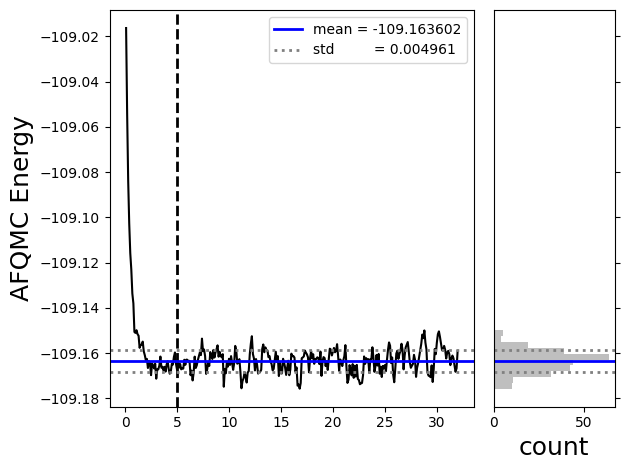

 [Result] 2.7  -109.16360241314825 0.0005924326535312885
Running AFQMC on dimer with bond length 3.0000 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_3.0000


converged SCF energy = -108.606225806528


CASSCF energy = -108.916484584344


CASCI E = -108.916484584344  E(CI) = -10.6184533706909  S^2 = 0.0000000


{'ci': array([[ 8.40809371e-01, -1.87808706e-07,  1.73417230e-07, ...,
        -7.68754607e-19, -8.35197797e-19, -2.54260306e-04],
       [-1.87808706e-07, -1.51254140e-01,  1.14898172e-01, ...,
         1.42255679e-18, -1.26216690e-18,  1.12541515e-10],
       [ 1.73417230e-07,  1.14898172e-01, -1.33720198e-01, ...,
         3.02308959e-20,  6.53096359e-19, -8.63291915e-11],
       ...,
       [-7.68754607e-19,  1.42255679e-18,  3.02308959e-20, ...,
        -9.19095756e-07,  3.80740274e-21,  1.21903533e-19],
       [-8.35197797e-19, -1.26216690e-18,  6.53096359e-19, ...,
         4.29989667e-21, -9.19095756e-07,  9.74561697e-20],
       [-2.54260306e-04,  1.12541515e-10, -8.63291915e-11, ...,
         1.21903533e-19,  9.74561697e-20,  1.31805583e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 5114
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performi

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 81.605253 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_3.0000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -109.087777 +/-   0.000618 4.95  5.0/32.0


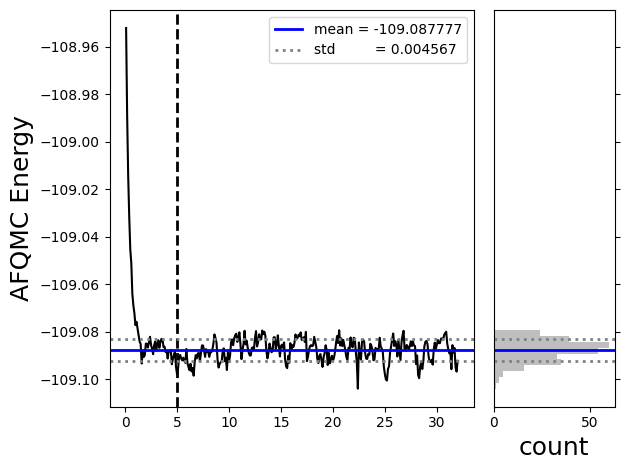

 [Result] 3.0  -109.08777678517845 0.0006180689563909054
Running AFQMC on dimer with bond length 3.6000 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_3.6000


converged SCF energy = -108.384756853955


CASSCF energy = -108.829399899001


CASCI E = -108.829399899001  E(CI) = -9.68145552116356  S^2 = 0.0000004


{'ci': array([[ 6.34787319e-01, -1.15096043e-06, -1.03708763e-06, ...,
        -1.71585473e-19,  6.39077828e-09,  1.66795437e-04],
       [-1.15096043e-06, -2.63527609e-01, -1.37764749e-01, ...,
        -6.04231251e-17, -7.35570294e-04,  5.37455515e-09],
       [-1.03708763e-06, -1.37764749e-01, -9.07166977e-02, ...,
        -3.28824982e-17, -4.06931971e-04,  3.36058962e-09],
       ...,
       [-1.96645674e-19, -6.04587422e-17, -3.29056428e-17, ...,
         4.18725592e-07, -2.18779169e-18,  1.61150437e-20],
       [ 6.39077826e-09, -7.35570278e-04, -4.06931850e-04, ...,
        -2.14348261e-18, -2.60459578e-05,  9.35522496e-09],
       [ 1.66795437e-04,  5.37455518e-09,  3.36058978e-09, ...,
         5.01068348e-20,  9.35522496e-09,  1.20784037e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}


number of determinants: 4958
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performing modified Cholesky decomposition on ERI tensor.
 # Generating Cholesky decomposition of ERIs.
 # max number of cholesky vectors = 280
        iteration      max_residual              time
                0  4.1222527349e+00  5.5630207062e-03
                1  4.1035346944e+00  2.6416778564e-04
                2  6.0642554578e-01  1.7809867859e-04
                3  5.7869663838e-01  1.7619132996e-04
                4  2.1905803904e-01  1.5640258789e-04
                5  2.1427962393e-01  1.6784667969e-04
                6  1.5487209282e-01  2.0432472229e-04
                7  1.5487209282e-01  1.9907951355e-04
                8  1.5463412581e-01  1.9335746765e-04
                9  1.5463412581e-01  1.9121170044e-04
               10  1.5170527889e-01  1.9955635071e-04
               11  1.5051729920e-01  1.9073486328

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 105.174001 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_3.6000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -108.996507 +/-   0.000552 5.05  5.0/32.0


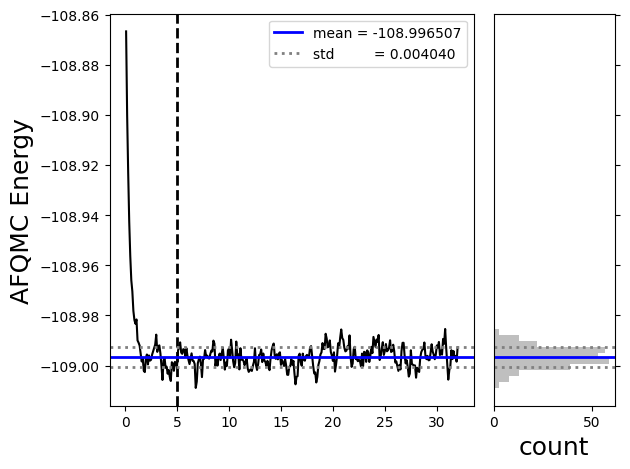

 [Result] 3.6  -108.9965069675349 0.0005522874484605909
Running AFQMC on dimer with bond length 4.2000 Angstroms
  [+] scratch_dir:  /mnt/home/beskridge/.scratch/N2_bondlength_4.2000


converged SCF energy = -108.222898618676


CASSCF energy = -108.804720452333


CASCI E = -108.804720452333  E(CI) = -9.17545047470611  S^2 = 0.0000067


{'ci': array([[-4.38774497e-01, -9.44819516e-08, -5.99203429e-07, ...,
        -5.00779405e-19, -8.92485411e-10,  4.21209014e-04],
       [-9.44819250e-08,  8.49565323e-03,  4.12048613e-02, ...,
        -9.16595430e-18, -1.11861686e-04, -2.67583944e-10],
       [-5.99203402e-07,  4.12048471e-02,  3.26765471e-01, ...,
        -6.88688495e-17, -8.78252813e-04, -3.23508435e-10],
       ...,
       [-4.99198463e-19, -8.21762868e-18, -6.45814639e-17, ...,
        -2.59784845e-07, -9.42854748e-20, -1.83825576e-19],
       [-8.92485516e-10, -1.11861726e-04, -8.78252837e-04, ...,
         1.30482233e-18,  1.96526348e-05, -1.47871952e-08],
       [ 4.21209014e-04, -2.67583940e-10, -3.23508334e-10, ...,
        -1.00069682e-19, -1.47871952e-08, -1.37972478e-05]],
      shape=(220, 220)), 'ncore': np.int64(4), 'ncas': np.int64(12)}
number of determinants: 4060
PHMSD trial wavfunction -> using uhf-like walkers
 # Transforming hcore and eri to MO basis.
 # Number of basis functions: 28.
 # Performi

Running AFQMC locally with 64 mpi tasks


AFQMC ran in 116.202900 seconds


====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/N2_bondlength_4.2000/qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = None            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -108.968161 +/-   0.001007 12.25  5.0/32.0


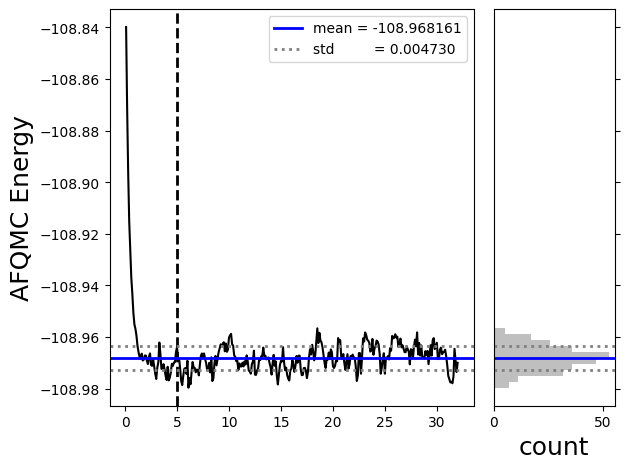

 [Result] 4.2  -108.96816087038029 0.00100748330359379


In [7]:
# we can simply use the automation function above to compute the PEC

num_mpi_tasks = 64 # set this based on your resources!

bondlengths = [2.118,2.4,2.7,3.0,3.6,4.2]
ndets_to_read = 500

energies = []
stochastic_uncertainties = []
for delta in bondlengths:
  _, E, dE = run_afqmc_on_dimer(delta,ndets_to_read,scratch_root_dir=home / ".scratch",num_mpi_tasks=num_mpi_tasks)
  energies.append(E)
  stochastic_uncertainties.append(dE)

### Plot the PEC

---

Now, we are ready to plot the PEC to see our results.


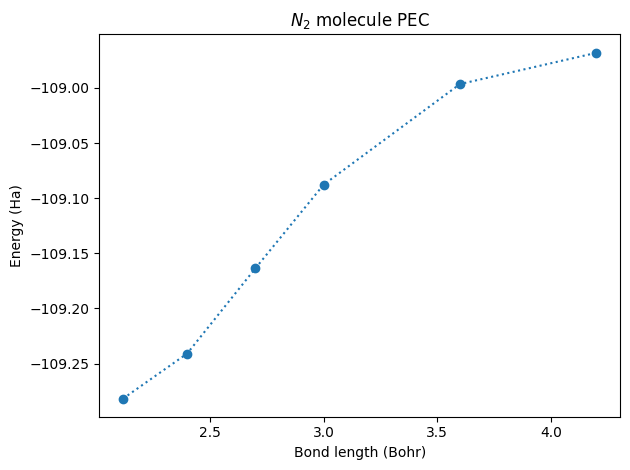

In [8]:
import matplotlib.pyplot as plt

plt.errorbar(bondlengths, energies, yerr=stochastic_uncertainties, fmt='o:', label="AFQMC/CASSCF")
plt.xlabel("Bond length (Bohr)")
plt.ylabel("Energy (Ha)")
plt.title(r"$N_2$ molecule PEC")
plt.tight_layout()
plt.show()

Compare this with the PEC generated using the data from the original paper.

<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/984d8f6514d4af38baf14fd45a2d29c0b42cf95c8335c9a92c7cefb169a830b7/NitrogenPecAbs.png">

# Summary

---

You have computed the potential energy curve (PEC) of the $N_2$ molecule, which is a standard benchmarking system in quantum chemistry.


## What you learned
---

<font size="4">

1. How to select the number of Slater determinants to include in the trial wavefunction, balancing computational cost and accuracy
2. How to automate the computation of a potential energy curve using afqmctools within Python
3. (optional) How to perform task 2 using bash and afqmctools instead

</font>